In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import yaml
from pathlib import Path
from dask.distributed import Client
import dask.dataframe as dd
import networkx as nx
import sys
import pandas as pd


import ipycytoscape
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import intervals
import pygtrie
import seaborn as sns
import gc


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
use_local=False
if not use_local:
    with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
        dlp_yaml = yaml.safe_load(file)
        app_root = dlp_yaml["app"]
else:
    app_root = str(Path(os.getcwd()).parent.parent)
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph1 import DFGrepInterferencePartitionBased, DFGrepBurstiness

if not use_local:
    dask_run_dir = os.path.join(app_root, "dfanalyzer", "dask", "run_dir")
    with open (os.path.join(dask_run_dir, f"scheduler_{os.getenv('USER')}.json"), "r") as f:
        dask_scheduler = json.load(f)["address"]
else:
    dask_scheduler = None

# App Name
# app_name = "montage-pegasus-2mass-2deg-4node" #cosmoflow cm1
# app_name = "1000_genome_pegasus_node_16"
# app_name = "cm1"
app_name = "deepspeed-dlio-step100"
# app_name = "deepspeed-dlio-scr-step100"
# app_name = "bert"
# app_name = "unet3d"
# app_name = "resnet50"
# app_name = "montage_pegasus-dss-1deg_node-16" #correct montage file
cp_dir = "/p/lustre3/pandey2/logs/Results_Checkpoint"

condition_fn = None #

if app_name == "montage_pegasus-dss-1deg_node-16":
    filename = "/p/lustre3/pandey2/logs/RAW_copy/montage_pegasus-dss-1deg_node-16/COMPACT/*.pfw.gz"

elif app_name == "cm1":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/cm1/APP/node-32/v1/COMPACT/*.pfw.gz"
    # cp_dir = "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "deepspeed-dlio-step100":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-step100/node-16/v1/COMPACT/*.pfw.gz"
    # filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-scr-step100/node-16/v1/COMPACT/*.pfw.gz"
    # cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "deepspeed-dlio-scr-step100":
    # filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-step100/node-16/v1/COMPACT/*.pfw.gz"
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-scr-step100/node-16/v1/COMPACT/*.pfw.gz"
    # cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "montage-mpi-2mass-7deg":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/montage/mpi-2mass-7deg/node-16/v1/RAW/*.pfw.gz"
    # cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name =="montage-pegasus-2mass-2deg-4node":
    # filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/montage/pegasus-2mass-2deg/node-4/v1/COMPACT/*.pfw.gz"
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/montage/pegasus-2mass-2deg/node-4/v1/RAW/*.pfw.gz"
    filename = "/p/lustre3/pandey2/logs/RAW_copy/montage-pegasus-2mass-2deg-4node/RAW/*.pfw.gz" # Raw Copied
    # cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "resnet50":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/resnet50/dlio-v100/node-4/v1/COMPACT/*.pfw.gz"
    # cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "unet3d":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/unet3d/dlio-v100/node-16/v2/COMPACT/*.pfw.gz"
    # cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "bert":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/bert/v100/node-16/v1/COMPACT/*.pfw.gz"
    # cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "1000_genome_pegasus_node_16":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/1000-genome/pegasus/node-16/v3/COMPACT/*.pfw.gz"
    # cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"
    
else:
    raise Exception("Unknown App name")


# Configuration 4 update log file dlp -> df
conf = update_dft_configuration(dask_scheduler=dask_scheduler, verbose=True, debug=True,
                                log_file=f"./dft_{os.getenv('USER')}.log", rebuild_index=False, time_approximate=True, 
                                host_pattern=r'lassen(\d+)', time_granularity=1e6, skip_hostname=True, conditions=condition_fn)
conf = get_dft_configuration()


# Setup
setup_logging()
setup_dask_cluster()
reset_dask_cluster()

[INFO] [18:07:58] Initialized Client with 576 workers and link http://134.9.71.20:8787/status [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:769]


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


[INFO] [18:08:09] Restarting all workers [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:761]


In [4]:
def all_mount_points():
    with open("/proc/mounts", "r") as file:
        mount_points = [line.split()[1] for line in file]
    with open("/usr/workspace/pandey2/lassen_mounts", "r") as file:
        mount_p = [line.split()[1] for line in file]
    return mount_points+mount_p

mount_points = all_mount_points()
trie = pygtrie.StringTrie(zip(mount_points, [True] * len(mount_points)))


In [5]:
def cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
    d = {}
    def find_mount_point(path,trie):
        mount_point = trie.longest_prefix(path)
        if mount_point:
            return mount_point.key
        return '/'.join(path.split('/', 3)[:3])

    if "M" == json_object["ph"] and "FH" == json_object["name"] and "args" in json_object and "name" in json_object["args"]:
        d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=json_object["args"]["name"])
    if "args" in json_object and "M" != json_object["ph"]:
        if "ret" in json_object["args"]:
            d["size"] = int(json_object["args"]["ret"]) 
    return d

load_cols = {'size': "int64[pyarrow]" }
load_cols_metadata = {"FH":{'mount_point':"string[pyarrow]" }}

In [6]:
analyzer = DFAnalyzer(filename,load_fn=cols_function, load_cols=load_cols, load_data={"mount_point":trie}, metadata_cols = load_cols_metadata)

[INFO] [18:08:20] Created index for 8 files [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:428]
[INFO] [18:08:20] Total size of all files are <dask.bag.core.Item object at 0x1554ac294f70> bytes [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:430]
[INFO] [18:08:20] test debug [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:433]
[INFO] [18:08:22] Loading 4041 batches out of 8 files and has 66139575 lines overall [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:444]
[INFO] [18:10:43] Loaded events [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:511]
[INFO] [18:10:43] Loaded plots with slope threshold: 45 [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:517]


,name,cat,type,pid,tid,ts,te,dur,tinterval,trange,compute_time,io_time,app_io_time,total_time,fhash,phase,size,hash,mount_point,value
hhash,,,,,,,,,,,,,,,,,,,,
16065659427268196451,3953873,3953873,3953873,3953873,3953873,3953873,3953873,3953873,0,3953873,0,1438697,0,3953873,2700689,3953873,2522293,0,0,0
9606232596457885775,3953876,3953876,3953876,3953876,3953876,3953876,3953876,3953876,0,3953876,0,1438700,0,3953876,2700692,3953876,2522294,0,0,0
5531434412913773887,3951177,3951177,3951177,3951177,3951177,3951177,3951177,3951177,0,3951177,0,1436481,0,3951177,2698233,3951177,2520132,0,0,0
7096598225222401591,3953875,3953875,3953875,3953875,3953875,3953875,3953875,3953875,0,3953875,0,1438699,0,3953875,2700691,3953875,2522294,0,0,0
1995665909820648179,3951232,3951232,3951232,3951232,3951232,3951232,3951232,3951232,0,3951232,0,1436536,0,3951232,2698288,3951232,2520129,0,0,0
12604783666688308289,3953870,3953870,3953870,3953870,3953870,3953870,3953870,3953870,0,3953870,0,1438694,0,3953870,2700686,3953870,2522291,0,0,0
14200274195875936004,3951234,3951234,3951234,3951234,3951234,3951234,3951234,3951234,0,3951234,0,1436538,0,3951234,2698290,3951234,2520131,0,0,0
6875378042338841042,3953877,3953877,3953877,3953877,3953877,3953877,3953877,3953877,0,3953877,0,1438701,0,3953877,2700693,3953877,2522293,0,0,0
8274241731122146018,3951262,3951262,3951262,3951262,3951262,3951262,3951262,3951262,0,3951262,0,1436542,0,3951262,2698318,3951262,2520143,0,0,0


In [6]:
analyzer.summary()

[INFO] [19:04:17] Total number of events in the workload are 409777294 [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:623]
[WARNING] [19:04:22] The max io_time 24179875 exceeds the time_granularity 1000000.0. Please adjust the time_granularity to 48e6 and rerun the analyzer. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:531]


╭──────────────────────────────────────────────────── Summary ────────────────────────────────────────────────────╮
│  Allocation    Scheduler Allocation Details                                                                     │
│                ├── Nodes: 16                                                                                    │
│                ├── Processes: 6098                                                                              │
│                ├── Thread allocations across nodes (includes dynamically created threads)                       │
│                │   ├── Compute: 0                                                                               │
│                │   └── I/O: 6098                                                                                │
│                └── Events Recorded: 410M                                                                        │
│  Dataset       Description of Dataset Used                                                                      │
│                └── Files: 25426951                                                                              │
│  I/O Behavior  Behavior of Application                                                                          │
│                ├── Split of Time in application                                                                 │
│                │   ├── Total Time: 5771.193 sec                                                                 │
│                │   └── Overall I/O: 2576.957 sec                                                                │
│                └── Metrics by function                                                                          │
│                    ├── Function       |count |                  size                   |                        │
│                    ├──                |      |min   |25    |mean  |median|75    |max   |                        │
│                    ├── __lxstat64     |221M  |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── lseek64        |109M  |NA    |15KB  |110KB |38KB  |293KB |369KB |                        │
│                    ├── read           |43M   |NA    |6KB   |52KB  |64KB  |64KB  |4MB   |                        │
│                    ├── opendir        |174K  |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── open64         |7M    |7     |8     |8     |8     |9     |9     |                        │
│                    ├── __fxstat64     |7M    |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── close          |7M    |NA    |NA    |NA    |NA    |NA    |NA    |                        │
│                    ├── readlink       |3K    |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── __xstat64      |8M    |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── rmdir          |7K    |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── access         |10K   |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── mkdir          |2K    |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── chmod          |7M    |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── open           |216K  |-1    |8     |32    |12    |31    |55    |                        │
│                    ├── fork           |11K   |NA    |9KB   |841KB |934KB |2MB   |4MB   |                        │
│                    ├── __xstat        |412K  |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── unlink         |7K    |NA    |nan   |nan   |NA    |nan   |NA    |                        │
│                    ├── __fxstat       |14K   |NA    |n

In [52]:
dir_w = "/p/lustre3/pandey2/logs/Results_Checkpoint/fhash/"+app_name+"/"
os.makedirs(dir_w, exist_ok=True)
analyzer.file_hash.reset_index().to_parquet(f'{dir_w}',engine='pyarrow',write_index=False)

In [7]:
hosts = analyzer.events.hhash.unique().compute().tolist()

In [8]:
# Keep only rows where hhash is in hosts[0]
analyzer.events1 = analyzer.events[analyzer.events["hhash"].isin(hosts)].copy()
# analyzer.events1 = analyzer.events[analyzer.events["hhash"] == hosts[0]].copy()

In [8]:
len(analyzer.events1)

32378942

In [9]:
analyzer.events1.name.unique().compute()

0         start
1         fopen
2        fclose
3       opendir
4        access
5     __xstat64
6        open64
7       lseek64
8          read
9         close
10         feof
11        fgets
12      __xstat
13         open
14     __fxstat
15         mmap
16       unlink
17      fopen64
18         fork
19        write
20          end
21        fread
22        fseek
23       remove
24       fwrite
25        fcntl
26       openat
27    faccessat
28          dup
29       rename
30    ftruncate
31        lseek
32        fputs
Name: name, dtype: string

In [9]:
if app_name in ["deepspeed-dlio-step100","deepspeed-dlio-scr-step100","resnet50","unet3d"]:
    df1 = analyzer.events1[~analyzer.events1['fhash'].isna()] 
    df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
    df3 = analyzer.host_hash.reset_index()[['hhash', 'name']]
    result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
    result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
    analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
    analyze_df['id'] = analyze_df.index
    analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
    data_df = analyze_df[analyze_df["name"].isin(data_calls)]
    metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]

elif app_name in ["montage-pegasus-2mass-2deg-4node","montage_pegasus-dss-1deg_node-16"]:
    df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
    df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
    df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
    df3 = df3.rename(columns={'hash':'hhash'})
    result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
    result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
    analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
    analyze_df['id'] = analyze_df.index
    analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
    data_df = analyze_df[analyze_df["name"].isin(data_calls)]
    metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]

elif app_name in ["1000_genome_pegasus_node_16"]:
    df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
    df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
    df3 = analyzer.host_hash.reset_index()[['hhash', 'name']] 
    result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
    result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
    analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
    analyze_df['id'] = analyze_df.index
    analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
    data_df = analyze_df[analyze_df["name"].isin(data_calls)]
    metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]


elif app_name == "bert":
    df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
    df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
    df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
    df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
    df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset
    result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
    result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
    analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
    analyze_df['id'] = analyze_df.index
    analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
    data_df = analyze_df[analyze_df["name"].isin(data_calls)]
    metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]

elif app_name in ["cm1"]:
    df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
    df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
    df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
    df1['hhash'] = df1['hhash'].str.replace('.0', '', regex=False)  # Remove '.0'
    df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
    df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset
    result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
    result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
    analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
    analyze_df['id'] = analyze_df.index
    analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'pwrite']
    data_df = analyze_df[analyze_df["name"].isin(data_calls)]
    metadata_df = analyze_df[~analyze_df["name"].isin(data_calls)]




In [10]:
# Intermediate Steps Required 
# Step 1: Filter correct rows and categorize based on the size

bins = [2**i for i in range(0, 21)] + [float('inf')] 
bin_labels = [
    f"2^{i} - 2^{i+1} B" if i < 10 else
    f"2^{i-10} KiB - 2^{i-9} KiB" if i < 20 else
    "1 MiB+"
    for i in range(0, 21)
]

def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df

def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df

data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')


# # step 2: Filter only interesting mount points
# # if computationally expensive and only few 
# if app_name == "resnet500":
#     mount_point_list = ["/p/lustre3","/dev","/proc","/sys","/dev","/dev/shm","/usr/workspace"]
#     data_df = data_df[data_df["mount_point"].isin(mount_point_list)]
#     metadata_df = metadata_df[metadata_df["mount_point"].isin(mount_point_list)]

# # if app_name == "deepspeed-dlio-scr-step100":
# #     mount_point_list = ['/l/ssd', '/p/lustre3','/usr/workspace', '/usr/WS2', '/sys', '/collab/usr/gapps', '/dev/shm','/dev','/proc', '/usr/tce','/usr/share','/var/tmp', '/g/g92']
# #     data_df = data_df[data_df["mount_point"].isin(mount_point_list)]
# #     metadata_df = metadata_df[metadata_df["mount_point"].isin(mount_point_list)]

# if app_name == 'montage-pegasus-2mass-2deg-4node':
#     mount_point_list = ['/p/lustre3', '/proc', '/usr/WS2', '/dev/shm', '/dev']
#     data_df = data_df[data_df["mount_point"].isin(mount_point_list)]
#     metadata_df = metadata_df[metadata_df["mount_point"].isin(mount_point_list)]

# if app_name == 'cm1':
#     mount_point_list =  ['/dev','/dev/shm', '/etc/libibverbs.d', '/p/lustre3','/sys','/tmp', '/usr/tce','/var/tmp', '/proc', '/usr/lib64', '/etc/psm3.conf', '/var']  
#     data_df = data_df[data_df["mount_point"].isin(mount_point_list)]
#     metadata_df = metadata_df[metadata_df["mount_point"].isin(mount_point_list)]

# if app_name == '1000_genome_pegasus_node_16':
#     mount_point_list =  ['/p/lustre3', '/usr/WS2', '/usr/workspace', '/dev', '/proc', '/sys']
#     data_df = data_df[data_df["mount_point"].isin(mount_point_list)]
#     metadata_df = metadata_df[metadata_df["mount_point"].isin(mount_point_list)]
    


 

In [22]:
data_df.head()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id,size_category
10420,read,POSIX,3130,26614156,26614372,216,26,/usr/WS2,corona202,10420,2^1 KiB - 2^2 KiB
10439,read,POSIX,1272,26640147,26640304,157,26,/usr/WS2,corona202,10439,2^0 KiB - 2^1 KiB
10476,read,POSIX,3416,26690101,26690565,464,26,/usr/WS2,corona202,10476,2^1 KiB - 2^2 KiB
10501,read,POSIX,2289,26694000,26694482,482,26,/usr/WS2,corona202,10501,2^1 KiB - 2^2 KiB
10582,read,POSIX,200,27296533,27297491,958,27,/usr/WS2,corona202,10582,2^7 - 2^8 B


## Data Interference calculation

In [11]:
#DATA Interference Computation
IFCalculator = DFGrepInterferencePartitionBased(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)


In [43]:
IFCalculator.computeDegree()


In [12]:
import time
import threading
from dask.distributed import Client

client = Client(dask_scheduler)   # or use your existing connected client

# Set this manually for the current run

peak_total_mem = 0
peak_worker_mem = {}
samples = []
monitoring = True

def monitor_worker_memory(interval=0.5):
    global peak_total_mem, peak_worker_mem, monitoring, samples

    while monitoring:
        info = client.scheduler_info()
        total_mem = 0

        row = {"time": time.time()}
        for addr, w in info["workers"].items():
            mem = w["metrics"]["memory"]   # bytes
            total_mem += mem
            peak_worker_mem[addr] = max(peak_worker_mem.get(addr, 0), mem)
            row[addr] = mem

        peak_total_mem = max(peak_total_mem, total_mem)
        row["total_mem"] = total_mem
        samples.append(row)

        time.sleep(interval)

# start background monitor
t = threading.Thread(target=monitor_worker_memory, daemon=True)
t.start()

# run your actual function
start = time.time()
result = IFCalculator.computeDegree()
runtime = time.time() - start

# stop monitor
monitoring = False
t.join()

# metrics

peak_total_mem_gb = peak_total_mem / 1e9
max_worker_mem_gb = max(peak_worker_mem.values()) / 1e9 if peak_worker_mem else 0


print("=" * 60)
print(f"Runtime (s):              {runtime:.2f}")
print(f"Peak total memory:        {peak_total_mem_gb:.2f} GB")
print(f"Peak max worker memory:   {max_worker_mem_gb:.2f} GB")

print("\nPeak memory per worker:")
for addr, mem in peak_worker_mem.items():
    print(f"  {addr:25s} {mem/1e9:8.2f} GB")
print("=" * 60)

Runtime (s):              11.45
Peak total memory:        186.94 GB
Peak max worker memory:   1.24 GB

Peak memory per worker:
  tcp://192.168.128.171:33537     0.25 GB
  tcp://192.168.128.171:33551     0.26 GB
  tcp://192.168.128.171:33739     0.61 GB
  tcp://192.168.128.171:34267     0.63 GB
  tcp://192.168.128.171:34429     0.26 GB
  tcp://192.168.128.171:34431     0.60 GB
  tcp://192.168.128.171:34623     0.26 GB
  tcp://192.168.128.171:34713     0.25 GB
  tcp://192.168.128.171:34855     0.26 GB
  tcp://192.168.128.171:35529     0.26 GB
  tcp://192.168.128.171:35635     0.26 GB
  tcp://192.168.128.171:35667     0.26 GB
  tcp://192.168.128.171:35669     0.26 GB
  tcp://192.168.128.171:35709     0.26 GB
  tcp://192.168.128.171:36341     0.26 GB
  tcp://192.168.128.171:36381     0.61 GB
  tcp://192.168.128.171:36505     0.25 GB
  tcp://192.168.128.171:36581     0.27 GB
  tcp://192.168.128.171:36771     0.26 GB
  tcp://192.168.128.171:36857     0.26 GB
  tcp://192.168.128.171:36999    

In [17]:
dask_scheduler

'tcp://134.9.71.20:10005'

In [45]:
import time
import threading
from dask.distributed import Client

client = Client(dask_scheduler)   # or use your existing connected client

# Set this manually for the current run

peak_total_mem = 0
peak_worker_mem = {}
samples = []
monitoring = True

def monitor_worker_memory(interval=0.5):
    global peak_total_mem, peak_worker_mem, monitoring, samples

    while monitoring:
        info = client.scheduler_info()
        total_mem = 0

        row = {"time": time.time()}
        for addr, w in info["workers"].items():
            mem = w["metrics"]["memory"]   # bytes
            total_mem += mem
            peak_worker_mem[addr] = max(peak_worker_mem.get(addr, 0), mem)
            row[addr] = mem

        peak_total_mem = max(peak_total_mem, total_mem)
        row["total_mem"] = total_mem
        samples.append(row)

        time.sleep(interval)

# start background monitor
t = threading.Thread(target=monitor_worker_memory, daemon=True)
t.start()

# run your actual function
start = time.time()
result = IFCalculator.computeInterferenceData()
runtime = time.time() - start

# stop monitor
monitoring = False
t.join()

# metrics

peak_total_mem_gb = peak_total_mem / 1e9
max_worker_mem_gb = max(peak_worker_mem.values()) / 1e9 if peak_worker_mem else 0


print("=" * 60)
print(f"Runtime (s):              {runtime:.2f}")
print(f"Peak total memory:        {peak_total_mem_gb:.2f} GB")
print(f"Peak max worker memory:   {max_worker_mem_gb:.2f} GB")

print("\nPeak memory per worker:")
for addr, mem in peak_worker_mem.items():
    print(f"  {addr:25s} {mem/1e9:8.2f} GB")
print("=" * 60)

[INFO] [14:14:22] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:826]
[INFO] [14:15:21] Computing IF for all  [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:839]


Runtime (s):              59.42
Peak total memory:        113.26 GB
Peak max worker memory:   1.39 GB

Peak memory per worker:
  tcp://192.168.128.171:32805     0.62 GB
  tcp://192.168.128.171:32811     0.28 GB
  tcp://192.168.128.171:33007     0.28 GB
  tcp://192.168.128.171:33175     0.56 GB
  tcp://192.168.128.171:33181     0.29 GB
  tcp://192.168.128.171:33397     0.36 GB
  tcp://192.168.128.171:33519     0.53 GB
  tcp://192.168.128.171:33783     0.30 GB
  tcp://192.168.128.171:33803     0.63 GB
  tcp://192.168.128.171:33859     0.28 GB
  tcp://192.168.128.171:33883     0.29 GB
  tcp://192.168.128.171:33969     0.29 GB
  tcp://192.168.128.171:34081     0.28 GB
  tcp://192.168.128.171:34323     0.32 GB
  tcp://192.168.128.171:34687     0.28 GB
  tcp://192.168.128.171:34691     0.63 GB
  tcp://192.168.128.171:34879     0.28 GB
  tcp://192.168.128.171:34885     0.29 GB
  tcp://192.168.128.171:34887     0.51 GB
  tcp://192.168.128.171:34985     0.57 GB
  tcp://192.168.128.171:35157    

In [54]:
IFCalculator.computeInterferenceData() 

[INFO] [10:33:41] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:826]


[INFO] [10:35:17] Computing IF for all  [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:839]


In [ ]:
IFCalculator.inter.query()

In [12]:
IFCalculator.inter.query('interference > 0 and deg_caller > 1').groupby('mount_point').count().compute()

,name,cat,size,size_category,ts,te,dur,trange,hostname,deg_caller,deg_other,min_dur,interference
mount_point,,,,,,,,,,,,,
/dev,9506,9506,9506,9506,9506,9506,9506,9506,9506,9506,9506,9506,9506
/dev/shm,28868,28868,28868,28868,28868,28868,28868,28868,28868,28868,28868,28868,28868
/p/lustre3,152061,152061,152061,152061,152061,152061,152061,152061,152061,152061,152061,152061,152061
/proc,43766,43766,43766,43766,43766,43766,43766,43766,43766,43766,43766,43766,43766
/sys,55830,55830,55830,55830,55830,55830,55830,55830,55830,55830,55830,55830,55830
/tmp,49,49,49,49,49,49,49,49,49,49,49,49,49
/usr/tce,2725,2725,2725,2725,2725,2725,2725,2725,2725,2725,2725,2725,2725
/var,24,24,24,24,24,24,24,24,24,24,24,24,24
/var/tmp,310,310,310,310,310,310,310,310,310,310,310,310,310


In [12]:
IFCalculator.inter.query('interference > 0 and deg_caller > 1').groupby('mount_point').count().compute()

KeyboardInterrupt: 

In [11]:
IFCalculator.write_checkpoint(id='inter', cp_dir=cp_dir)

In [15]:
IFCalculator.inter.query('interference > 0 and deg_caller > 1').compute()

,name,cat,size,size_category,ts,te,dur,trange,mount_point,hostname,deg_caller,deg_other,min_dur,interference
3539,read,POSIX,5412,2^2 KiB - 2^3 KiB,32316195,32316948,753,1,/collab/usr/gapps,corona202,2,1.0,4.0,0.005312
3868,read,POSIX,289,2^8 - 2^9 B,31650827,31651360,533,1,/usr/WS2,corona202,2,1.0,2.0,0.003752
3896,read,POSIX,22552,2^4 KiB - 2^5 KiB,31730406,31732770,2364,1,/usr/WS2,corona202,2,1.0,5.0,0.002115
3907,read,POSIX,8885,2^3 KiB - 2^4 KiB,31751905,31752294,389,1,/usr/WS2,corona202,2,1.0,5.0,0.012853
3918,read,POSIX,8192,2^2 KiB - 2^3 KiB,31757693,31757697,4,1,/usr/WS2,corona202,2,1.0,5.0,1.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3677,read,POSIX,730,2^9 - 2^10 B,24208616,24209336,720,0,/usr/WS2,corona193,2,1.0,3.0,0.004167
3691,read,POSIX,420,2^8 - 2^9 B,24259458,24259579,121,0,/usr/WS2,corona193,2,1.0,3.0,0.024793
3705,read,POSIX,27332,2^4 KiB - 2^5 KiB,24302613,24303478,865,0,/usr/WS2,corona193,2,1.0,3.0,0.003468
3730,read,POSIX,7845,2^2 KiB - 2^3 KiB,24373964,24374258,294,0,/usr/WS2,corona193,2,1.0,3.0,0.010204


# Metadata Interference Computation

In [16]:
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)
# IFCalculator_Metadata.get_degree()
# IFCalculator_Metadata.compute_interference()
# IFCalculator_Metadata.write_checkpoint(id="inter_metadata", cp_dir = cp_dir)

In [17]:
IFCalculator_Metadata.get_degree()

In [ ]:
IFCalculator_Metadata.compute_interference()

In [ ]:
IFCalculator_Metadata.write_checkpoint(id="inter_metadata", cp_dir = cp_dir)

,name,pid,tid,hhash
hash,,,,
1.181405777718347e+19,corona188,1027673,1027673,11814057777183469021
6.968018510730724e+18,corona239,2055310,2055310,6968018510730723892
6.598453666498801e+18,corona234,2382606,2382606,6598453666498800848
1.0812942414789165e+19,corona236,269213,269213,10812942414789164657
1.1063386352187771e+18,corona238,2440296,2440296,1106338635218777131


# Burstiness Computation

In [76]:
delta = data_df.dur.max().compute()
BurstCalculator = DFGrepBurstiness(data_df, app_name=app_name, operation="data", delta = delta, cp_dir=cp_dir, existing=False)
# BurstCalculator.compute_burstiness()
# BurstCalculator.write_checkpoint(id="ddf_bur",cp_dir=cp_dir)

In [77]:
import time
import threading
from dask.distributed import Client

client = Client(dask_scheduler)   # or use your existing connected client

# Set this manually for the current run

peak_total_mem = 0
peak_worker_mem = {}
samples = []
monitoring = True

def monitor_worker_memory(interval=0.5):
    global peak_total_mem, peak_worker_mem, monitoring, samples

    while monitoring:
        info = client.scheduler_info()
        total_mem = 0

        row = {"time": time.time()}
        for addr, w in info["workers"].items():
            mem = w["metrics"]["memory"]   # bytes
            total_mem += mem
            peak_worker_mem[addr] = max(peak_worker_mem.get(addr, 0), mem)
            row[addr] = mem

        peak_total_mem = max(peak_total_mem, total_mem)
        row["total_mem"] = total_mem
        samples.append(row)

        time.sleep(interval)

# start background monitor
t = threading.Thread(target=monitor_worker_memory, daemon=True)
t.start()

# run your actual function
start = time.time()
BurstCalculator.compute_burstiness()
runtime = time.time() - start

# stop monitor
monitoring = False
t.join()

# metrics

peak_total_mem_gb = peak_total_mem / 1e9
max_worker_mem_gb = max(peak_worker_mem.values()) / 1e9 if peak_worker_mem else 0


print("=" * 60)
print(f"Runtime (s):              {runtime:.2f}")
print(f"Peak total memory:        {peak_total_mem_gb:.2f} GB")
print(f"Peak max worker memory:   {max_worker_mem_gb:.2f} GB")

print("\nPeak memory per worker:")
for addr, mem in peak_worker_mem.items():
    print(f"  {addr:25s} {mem/1e9:8.2f} GB")
print("=" * 60)

Runtime (s):              0.17
Peak total memory:        103.21 GB
Peak max worker memory:   0.74 GB

Peak memory per worker:
  tcp://192.168.128.171:32805     0.42 GB
  tcp://192.168.128.171:32811     0.28 GB
  tcp://192.168.128.171:33007     0.28 GB
  tcp://192.168.128.171:33175     0.56 GB
  tcp://192.168.128.171:33181     0.29 GB
  tcp://192.168.128.171:33397     0.35 GB
  tcp://192.168.128.171:33519     0.43 GB
  tcp://192.168.128.171:33783     0.29 GB
  tcp://192.168.128.171:33803     0.49 GB
  tcp://192.168.128.171:33859     0.28 GB
  tcp://192.168.128.171:33883     0.28 GB
  tcp://192.168.128.171:33969     0.29 GB
  tcp://192.168.128.171:34081     0.28 GB
  tcp://192.168.128.171:34323     0.29 GB
  tcp://192.168.128.171:34687     0.28 GB
  tcp://192.168.128.171:34691     0.47 GB
  tcp://192.168.128.171:34879     0.28 GB
  tcp://192.168.128.171:34885     0.29 GB
  tcp://192.168.128.171:34887     0.42 GB
  tcp://192.168.128.171:34985     0.46 GB
  tcp://192.168.128.171:35157     

In [9]:
BurstCalculator.write_checkpoint(id="ddf_bur",cp_dir=cp_dir)

In [12]:
BurstCalculator.ddf_bur.head()

,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,group_key,b_id
0,443935,read,POSIX,65536,3302000003,3302000023,20,3302,/usr/WS2,corona243,"(3302, '/usr/WS2')",443935
1,72186,read,POSIX,65536,3302000073,3302000096,23,3302,/usr/WS2,corona188,"(3302, '/usr/WS2')",443935
2,443940,read,POSIX,65536,3302000080,3302000098,18,3302,/usr/WS2,corona243,"(3302, '/usr/WS2')",443935
3,72189,read,POSIX,65536,3302000121,3302000144,23,3302,/usr/WS2,corona188,"(3302, '/usr/WS2')",443935
4,443943,read,POSIX,65536,3302000123,3302000138,15,3302,/usr/WS2,corona243,"(3302, '/usr/WS2')",443935


<!-- delta = data_df.dur.max().compute() -->


In [ ]:
#Scalability Visualization

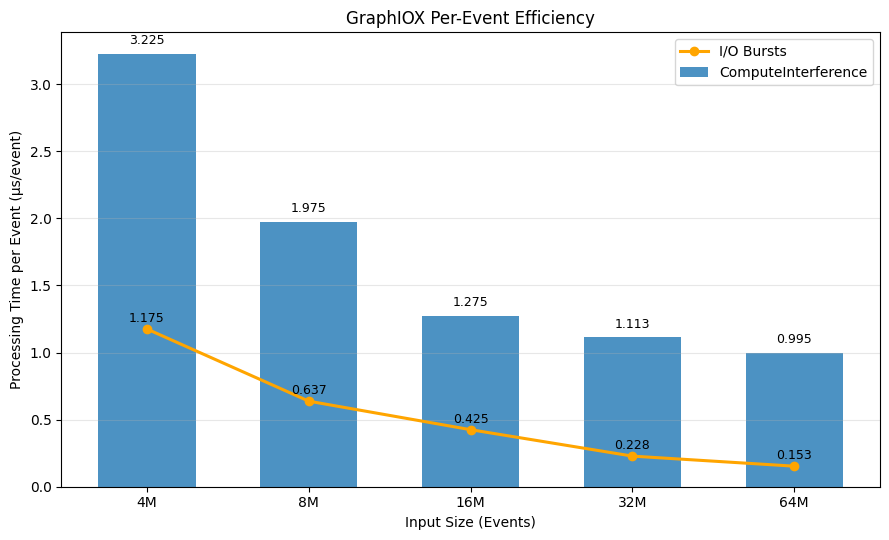

In [75]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["4M","8M","16M","32M","64M"]
x = np.arange(len(labels))

interference = [3.2250, 1.9750, 1.2750, 1.1125, 0.9953]
bursts = [1.1750, 0.6375, 0.4250, 0.2281, 0.1531]

plt.figure(figsize=(9,5.5))

# Bars
bars = plt.bar(x, interference, width=0.6, alpha=0.8, label="ComputeInterference")

# Orange line
plt.plot(
    x, bursts,
    marker="o",
    linewidth=2.2,
    color="orange",
    label="I/O Bursts"
)

plt.xticks(x, labels)
plt.xlabel("Input Size (Events)")
plt.ylabel("Processing Time per Event (µs/event)")
plt.title("GraphIOX Per-Event Efficiency")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()

for rect, val in zip(bars, interference):
    plt.text(rect.get_x()+rect.get_width()/2, val+0.05,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)

for xi, val in zip(x, bursts):
    plt.text(xi, val+0.03,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
from dask.distributed import Client

client = Client()

info = client.scheduler_info()
for w in info["workers"].values():
    print(w["memory_limit"], w["metrics"]["memory"])